<a href="https://colab.research.google.com/github/majdsabha/Project-2/blob/main/Project_2_prat_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 2 -prat 1

-Student Name : Majd Sabha

In [1]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, recall_score
from sklearn.decomposition import PCA




In [3]:
# Load the dataset
file_path = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week05/Data/adult.csv'

df = pd.read_csv(file_path)

# Preview the data
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# Check number of rows and columns
df.shape

(48842, 15)

In [5]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
# Check missing values
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(52)

In [8]:
# Replace '?' values with NaN
df = df.replace('?', np.nan)

# Check missing values again
df.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [9]:

# Drop duplicate rows
df = df.drop_duplicates()

# Check duplicates again
df.duplicated().sum()

np.int64(0)

In [10]:
# Check shape after removing duplicates
df.shape

(48790, 15)

In [11]:
# Check target distribution as percentage
df['income'].value_counts(normalize=True)

,proportion
income,
<=50K,0.760586
>50K,0.239414


In [12]:
# Check categorical columns
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

In [13]:
# Check unique values in categorical columns
for col in cat_cols:
    print(f'\n{col}')
    print(df[col].value_counts())


workclass
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64

marital-status
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64

occupation
occupation
Prof-specialty       6165
Craft-repair         61

In [14]:
# Fill missing categorical values with 'Unknown'
df[['workclass', 'occupation', 'native-country']] = df[
    ['workclass', 'occupation', 'native-country']
].fillna('Unknown')

# Check missing values again
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [15]:
# Check final shape after cleaning
df.shape

(48790, 15)

## Dataset Selection

### What is the target?
The target is `income`. It is a binary classification target with two classes: `<=50K` and `>50K`. The goal is to predict whether a person's income is greater than 50K or not.

### What does one row represent?
Each row represents one person, including demographic and work-related information such as age, workclass, education, occupation, hours worked per week, and income category.

### How many features does the data have?
The dataset originally has 15 columns. Since `income` is the target, the model will use 14 columns as features.

### How many rows are in the dataset?
The dataset originally had 48,842 rows. After removing 52 duplicate rows, the cleaned dataset has 48,790 rows.

### What opportunities exist for dimensionality reduction or feature selection with this dataset?
This dataset contains several categorical features, such as workclass, education, marital-status, occupation, relationship, race, gender, and native-country. After one-hot encoding, these features will create many new columns. Therefore, feature selection can help identify the most important predictors. Dimensionality reduction may also be useful if the encoded dataset becomes very large.

### What challenges do you foresee in cleaning, exploring, or modeling this dataset?
Some values were written as `?`, which had to be treated as missing values. The dataset also contains both numerical and categorical features, so preprocessing will require scaling numerical features and encoding categorical features. Another challenge is class imbalance because about 76% of people earn `<=50K`, while only about 24% earn `>50K`.

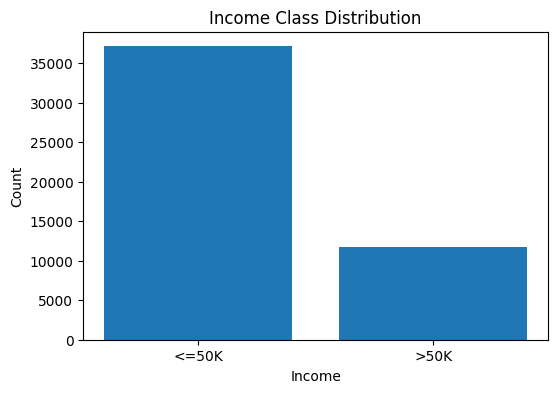

,count
income,
<=50K,37109
>50K,11681


In [16]:
#. Exploratory Visualizations

# Target distribution

income_counts = df['income'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(income_counts.index, income_counts.values)
plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

income_counts

### Income Class Distribution

This chart shows the distribution of the target variable `income`. Most people in the dataset earn `<=50K`, while a smaller group earns `>50K`.

There are 37,109 people in the `<=50K` class and 11,681 people in the `>50K` class. This means about 76% of the dataset belongs to the `<=50K` class, while about 24% belongs to the `>50K` class.

This shows that the target is imbalanced, so the model may be more likely to predict the majority class `<=50K`.

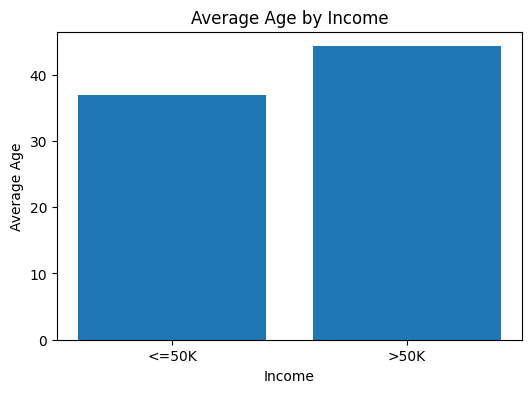

,age
income,
<=50K,36.882751
>50K,44.276004


In [17]:
# Average age by income

age_by_income = df.groupby('income')['age'].mean()

plt.figure(figsize=(6, 4))
plt.bar(age_by_income.index, age_by_income.values)
plt.title('Average Age by Income')
plt.xlabel('Income')
plt.ylabel('Average Age')
plt.show()

age_by_income

### Average Age by Income

This chart compares the average age for each income class. People who earn `>50K` have a higher average age, around 44.3 years, while people who earn `<=50K` have an average age of about 36.9 years.

This suggests that age may be related to income. Older people may have more work experience, more stable jobs, or higher positions, which can increase their chance of earning more than 50K.

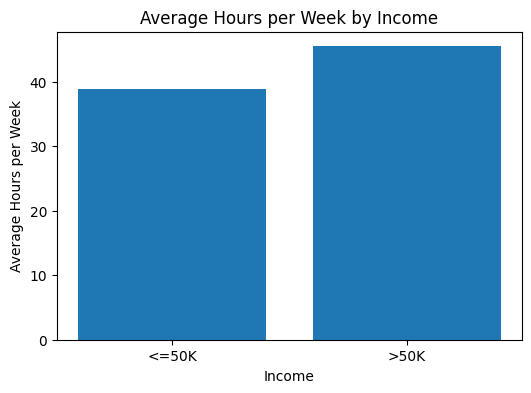

,hours-per-week
income,
<=50K,38.842976
>50K,45.454584


In [18]:
# Average hours worked per week by income

hours_by_income = df.groupby('income')['hours-per-week'].mean()

plt.figure(figsize=(6, 4))
plt.bar(hours_by_income.index, hours_by_income.values)
plt.title('Average Hours per Week by Income')
plt.xlabel('Income')
plt.ylabel('Average Hours per Week')
plt.show()

hours_by_income

### Average Hours per Week by Income

This chart compares the average number of hours worked per week for each income class. People who earn `>50K` work around 45.5 hours per week on average, while people who earn `<=50K` work around 38.8 hours per week on average.

This suggests that working more hours per week may be related to having a higher income. However, hours worked alone may not fully explain income, because other factors such as education, occupation, and work experience may also be important.

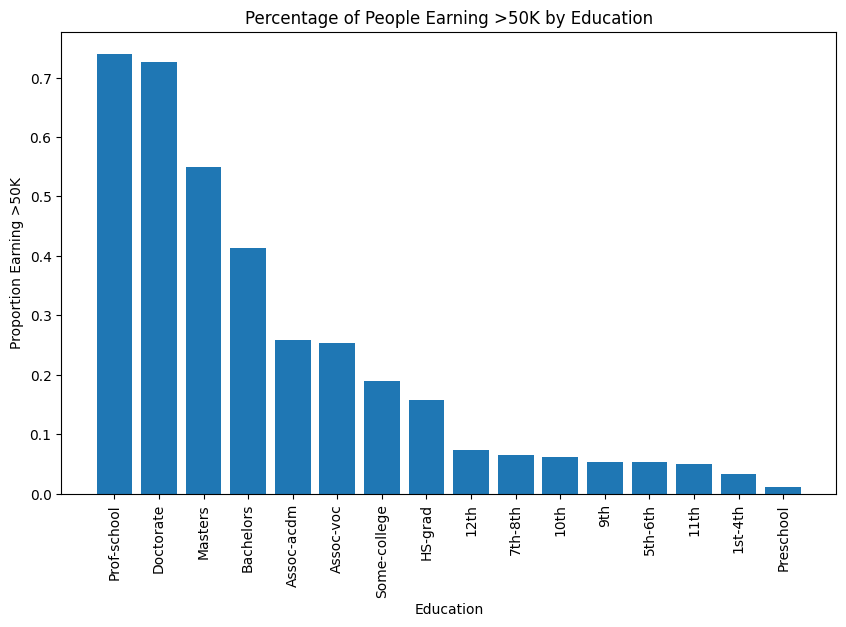

,income_binary
education,
Prof-school,0.739808
Doctorate,0.725589
Masters,0.549322
Bachelors,0.413204
Assoc-acdm,0.257964
Assoc-voc,0.253398
Some-college,0.189727
HS-grad,0.158592
12th,0.073282


In [19]:
# Create binary target for exploration
df['income_binary'] = (df['income'] == '>50K').astype(int)

# Calculate percentage of people earning >50K by education
education_income = df.groupby('education')['income_binary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(education_income.index, education_income.values)
plt.title('Percentage of People Earning >50K by Education')
plt.xlabel('Education')
plt.ylabel('Proportion Earning >50K')
plt.xticks(rotation=90)
plt.show()

education_income

### Percentage of People Earning >50K by Education

This chart shows the proportion of people earning `>50K` for each education level. Higher education levels such as `Prof-school`, `Doctorate`, `Masters`, and `Bachelors` have the highest proportions of people earning more than 50K.

For example, around 74% of people with `Prof-school` education and around 73% of people with a `Doctorate` earn more than 50K. On the other hand, lower education levels such as `Preschool`, `1st-4th`, `11th`, and `5th-6th` have much lower proportions.

This suggests that education level is strongly related to income and may be an important feature for predicting whether a person earns more than 50K.

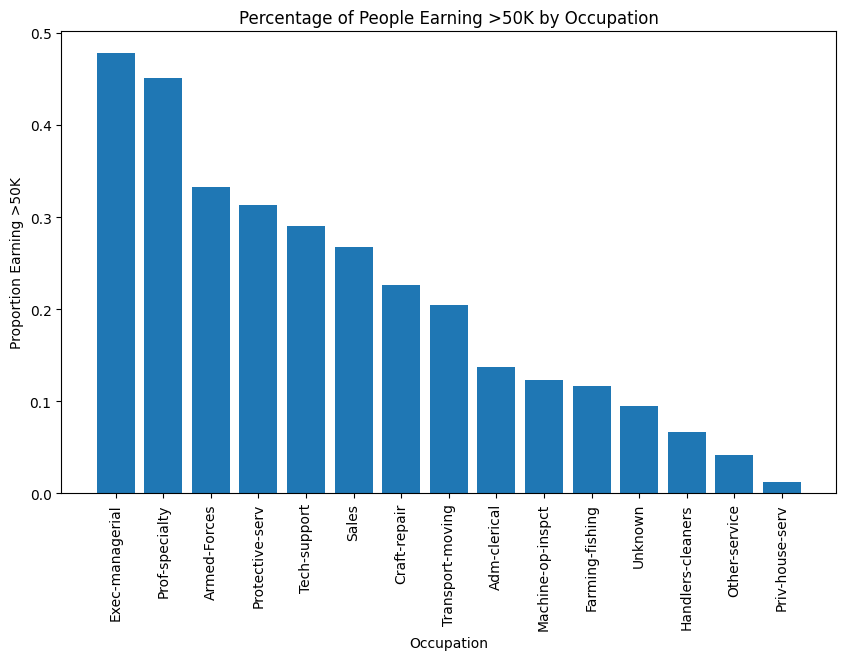

,income_binary
occupation,
Exec-managerial,0.477803
Prof-specialty,0.451257
Armed-Forces,0.333333
Protective-serv,0.313646
Tech-support,0.290657
Sales,0.268133
Craft-repair,0.226483
Transport-moving,0.204246
Adm-clerical,0.136996


In [20]:
# Percentage of people earning >50K by occupation

occupation_income = df.groupby('occupation')['income_binary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(occupation_income.index, occupation_income.values)
plt.title('Percentage of People Earning >50K by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Proportion Earning >50K')
plt.xticks(rotation=90)
plt.show()

occupation_income

### Percentage of People Earning >50K by Occupation

This chart shows the proportion of people earning `>50K` for each occupation. The occupations with the highest proportions of people earning more than 50K are `Exec-managerial` and `Prof-specialty`.

Around 48% of people in `Exec-managerial` and around 45% of people in `Prof-specialty` earn more than 50K. In contrast, occupations such as `Priv-house-serv`, `Other-service`, and `Handlers-cleaners` have much lower proportions.

This suggests that occupation is strongly related to income and may be an important feature for predicting whether a person earns more than 50K.

In [21]:
#Choose a model
# Define features and target

X = df.drop(columns=['income', 'income_binary'], errors='ignore')
y = df['income']


In [22]:

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y )



In [23]:
# Identify numeric and categorical columns

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include='object').columns

In [24]:
# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [25]:
# Create default Random Forest model pipeline
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

# Fit the model
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

Classification Report: Training Data
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     29687
        >50K       1.00      1.00      1.00      9345

    accuracy                           1.00     39032
   macro avg       1.00      1.00      1.00     39032
weighted avg       1.00      1.00      1.00     39032

Classification Report: Test Data
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      7422
        >50K       0.73      0.63      0.68      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.78      0.79      9758
weighted avg       0.85      0.85      0.85      9758



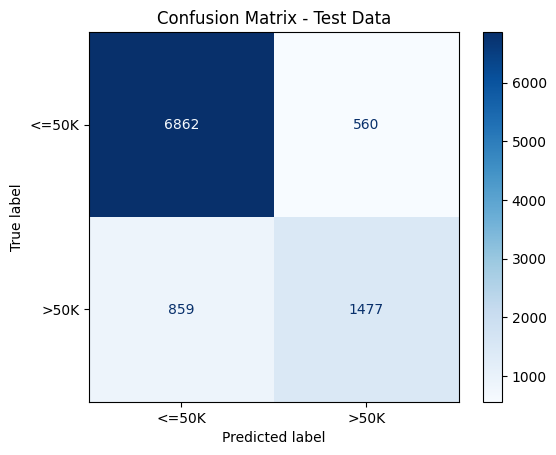

In [26]:
# Make predictions
train_preds = rf_pipe.predict(X_train)
test_preds = rf_pipe.predict(X_test)

# Classification reports
print("Classification Report: Training Data")
print(classification_report(y_train, train_preds))

print("Classification Report: Test Data")
print(classification_report(y_test, test_preds))

# Confusion matrix for test data
ConfusionMatrixDisplay.from_estimator(
    rf_pipe,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title('Confusion Matrix - Test Data')
plt.show()

## Default Model Evaluation - Focus on Recall

I selected a default Random Forest Classifier for this classification task. The data was preprocessed using a pipeline that scales numerical features and one-hot encodes categorical features. The model was evaluated using a classification report and a confusion matrix.

Since the goal is to correctly identify people who earn `>50K`, recall is an important metric. Recall tells us how many of the actual `>50K` cases the model successfully detected.

On the test data, the model achieved an overall accuracy of 0.85. For the `<=50K` class, the recall was 0.92, which means the model correctly identified most people who actually earn `<=50K`.

For the `>50K` class, the recall was 0.63. This means the model correctly identified about 63% of the people who actually earn more than 50K, but it missed about 37% of them and predicted them as `<=50K`.

From the confusion matrix, the model correctly predicted 1,477 people as `>50K`, but misclassified 859 actual `>50K` people as `<=50K`.

This is important from a business perspective because missing people who actually earn `>50K` means the model may fail to identify valuable high-income individuals. Therefore, even though the accuracy is good, the recall for the `>50K` class should be improved in future model tuning.

The model also achieved perfect scores on the training data, which suggests possible overfitting. However, this default model is still useful as a baseline before improving the model and analyzing feature importance.

In [27]:
# Create recall scorer for the positive class >50K
recall_scorer = make_scorer(
    recall_score,
    pos_label='>50K'
)

# Calculate permutation importance based on recall
perm_importance = permutation_importance(
    rf_pipe,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring=recall_scorer
)

In [28]:
# Create a dataframe for permutation importance results
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean
})

# Sort features by importance
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Show top 10 features
top_10_features = importance_df.head(10)

top_10_features

,feature,importance
5,marital-status,0.155051
7,relationship,0.141182
0,age,0.079024
6,occupation,0.076284
4,educational-num,0.070548
10,capital-gain,0.068322
12,hours-per-week,0.044606
9,gender,0.035188
3,education,0.030137
11,capital-loss,0.023973


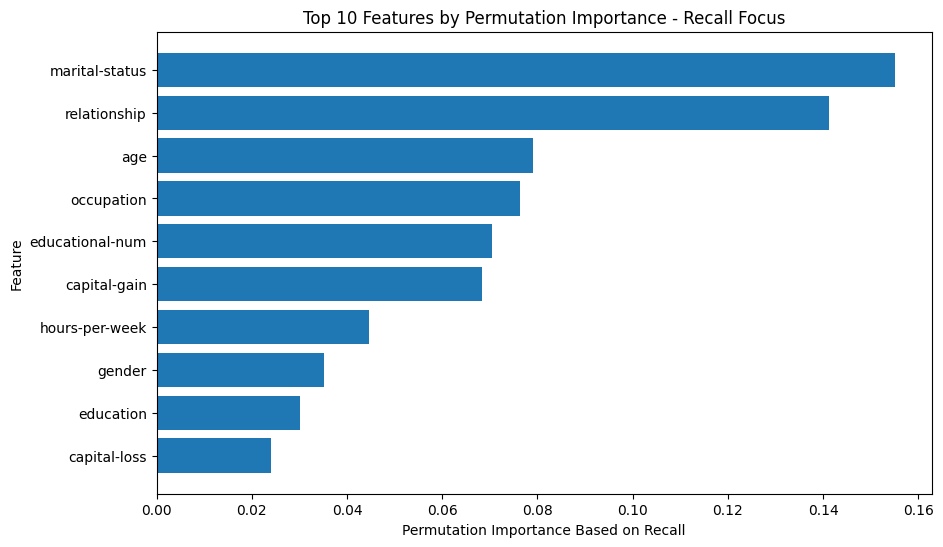

In [29]:
# Plot top 10 important features based on recall

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['feature'], top_10_features['importance'])
plt.xlabel('Permutation Importance Based on Recall')
plt.ylabel('Feature')
plt.title('Top 10 Features by Permutation Importance - Recall Focus')
plt.gca().invert_yaxis()
plt.show()

## Permutation Importance - Recall Focus

I used permutation importance with recall as the scoring metric because the goal is to identify people who actually earn `>50K`. Accuracy can be misleading because the dataset is imbalanced, with most people earning `<=50K`.

The most important features based on recall were `marital-status`, `relationship`, `age`, `occupation`, `educational-num`, `capital-gain`, `hours-per-week`, `gender`, `education`, and `capital-loss`.

These features make sense for the business case. Marital status and relationship may reflect household structure and financial responsibilities. Age can represent work experience and career stage. Occupation and education are strongly related to earning potential. Capital gain and capital loss may indicate investment income or financial activity, while hours worked per week can also be connected to income level.

Since these features help the model identify higher-income individuals, they are useful for understanding what factors are associated with earning more than 50K.

## Explanatory Visualizations

I selected `marital-status` and `relationship` because they were the top two features from the permutation importance results using recall as the scoring metric. These visualizations show the relationship between each selected feature and the target variable `income`.

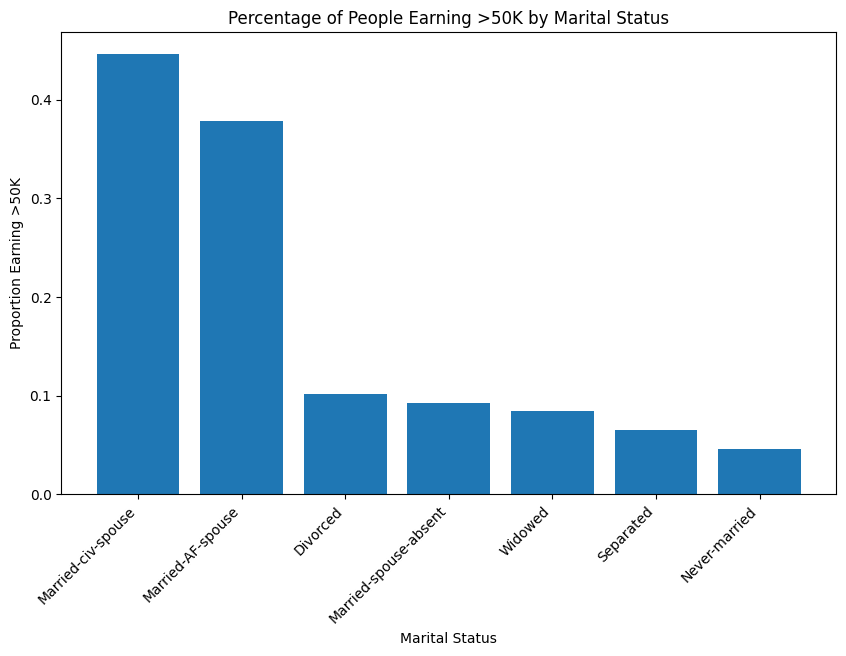

,income_binary
marital-status,
Married-civ-spouse,0.446124
Married-AF-spouse,0.378378
Divorced,0.101207
Married-spouse-absent,0.092504
Widowed,0.084321
Separated,0.064706
Never-married,0.045579


In [30]:
#Create Explanatory Visualizations for the most important features
#Explanatory Visualization 1: marital-status

# Explanatory visualization 1: Income rate by marital status

marital_income = (
    df.groupby('marital-status')['income_binary'].mean().sort_values(ascending=False))

plt.figure(figsize=(10, 6))
plt.bar(marital_income.index, marital_income.values)
plt.title('Percentage of People Earning >50K by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Proportion Earning >50K')
plt.xticks(rotation=45, ha='right')
plt.show()

marital_income

### Income by Marital Status

This visualization shows the proportion of people earning `>50K` for each marital status category. The highest proportion is for `Married-civ-spouse`, where about 44.6% of people earn more than 50K. `Married-AF-spouse` also has a relatively high proportion, around 37.8%.

On the other hand, categories such as `Never-married`, `Separated`, and `Widowed` have much lower proportions of people earning more than 50K.

This suggests that marital status is strongly related to income. This may be because marital status can reflect life stage, age, household structure, and financial stability. Since `marital-status` was the most important feature based on permutation importance, this visualization helps explain why it was useful for identifying the `>50K` income class.

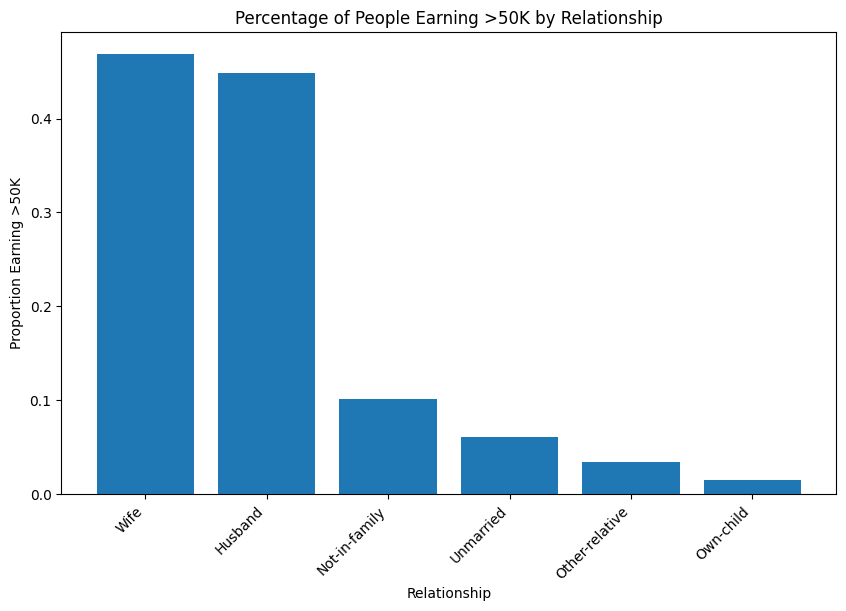

,income_binary
relationship,
Wife,0.468897
Husband,0.448663
Not-in-family,0.101617
Unmarried,0.060304
Other-relative,0.034529
Own-child,0.014665


In [31]:
# Explanatory visualization 2: Income rate by relationship

relationship_income = (
    df.groupby('relationship')['income_binary']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(relationship_income.index, relationship_income.values)
plt.title('Percentage of People Earning >50K by Relationship')
plt.xlabel('Relationship')
plt.ylabel('Proportion Earning >50K')
plt.xticks(rotation=45, ha='right')
plt.show()

relationship_income

### Income by Relationship

This visualization shows the proportion of people earning `>50K` for each relationship category. The highest proportions are for `Wife` and `Husband`. About 46.9% of people in the `Wife` category and about 44.9% of people in the `Husband` category earn more than 50K.

Other categories, such as `Not-in-family`, `Unmarried`, `Other-relative`, and `Own-child`, have much lower proportions of people earning more than 50K. The `Own-child` category has the lowest proportion, around 1.5%.

This suggests that relationship status is strongly related to income. It may reflect household role, age, career stage, and financial responsibility. Since `relationship` was the second most important feature based on permutation importance, this visualization helps explain why it was useful for identifying the `>50K` income class.

Overall, both visualizations show that household and relationship-related features are strongly connected to the target variable. This supports the permutation importance results, where `marital-status` and `relationship` were the most important features for identifying the `>50K` income class.

# Part 2: Feature Engineering and Feature Selection

In [33]:
# Step 1: Save baseline recall from Part 1

from sklearn.metrics import recall_score

# Predict using the baseline model from Part 1
baseline_test_preds = rf_pipe.predict(X_test)

# Calculate recall for the >50K class
baseline_recall = recall_score(
    y_test,
    baseline_test_preds,
    pos_label='>50K')

baseline_recall

0.632277397260274

### Baseline Model from Part 1

The baseline model from Part 1 is used for comparison. Since the goal is to identify people who earn `>50K`, recall for the `>50K` class is used as the main evaluation metric.

The baseline recall for the `>50K` class was approximately 0.63, meaning the model correctly identified about 63% of the actual high-income individuals.

In [35]:
# Step 2: Preprocess data before PCA
# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include='object').columns

# Create preprocessing pipeline for PCA
fe_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Fit only on training data
X_train_processed = fe_preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = fe_preprocessor.transform(X_test)

# Check shapes
X_train_processed.shape, X_test_processed.shape

((39032, 108), (9758, 108))

### Preprocessing for PCA

Before applying PCA, I created a preprocessing pipeline to convert the data into a numerical format. Numerical features were scaled using `StandardScaler`, and categorical features were encoded using `OneHotEncoder`.

The preprocessor was fit only on the training data and then used to transform the test data. This avoids data leakage and prepares the data for PCA.

In [36]:
# Step 3: Apply PCA to create 3 principal components

pca = PCA(n_components=3, random_state=42)

# Fit PCA only on training data
X_train_pca = pca.fit_transform(X_train_processed)

# Transform test data using the fitted PCA
X_test_pca = pca.transform(X_test_processed)

# Check PCA shapes
X_train_pca.shape, X_test_pca.shape

((39032, 3), (9758, 3))

### PCA Feature Engineering

I applied PCA to create 3 principal components from the preprocessed features. PCA was fit only on the training data, and then the fitted PCA object was used to transform the test data. This avoids data leakage and keeps the testing data unseen during training.

In [37]:
# Step 4: Combine PCA components with original processed features

X_train_engineered = np.hstack([X_train_processed, X_train_pca])
X_test_engineered = np.hstack([X_test_processed, X_test_pca])

# Check new shapes
X_train_engineered.shape, X_test_engineered.shape

((39032, 111), (9758, 111))

### Combine Engineered Features

The 3 PCA components were combined with the original preprocessed features. This created a new engineered feature set that includes both the original transformed features and the new PCA features.

Classification Report: Training Data
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     29687
        >50K       1.00      1.00      1.00      9345

    accuracy                           1.00     39032
   macro avg       1.00      1.00      1.00     39032
weighted avg       1.00      1.00      1.00     39032

Classification Report: Test Data
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7422
        >50K       0.73      0.62      0.67      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.77      0.79      9758
weighted avg       0.85      0.85      0.85      9758



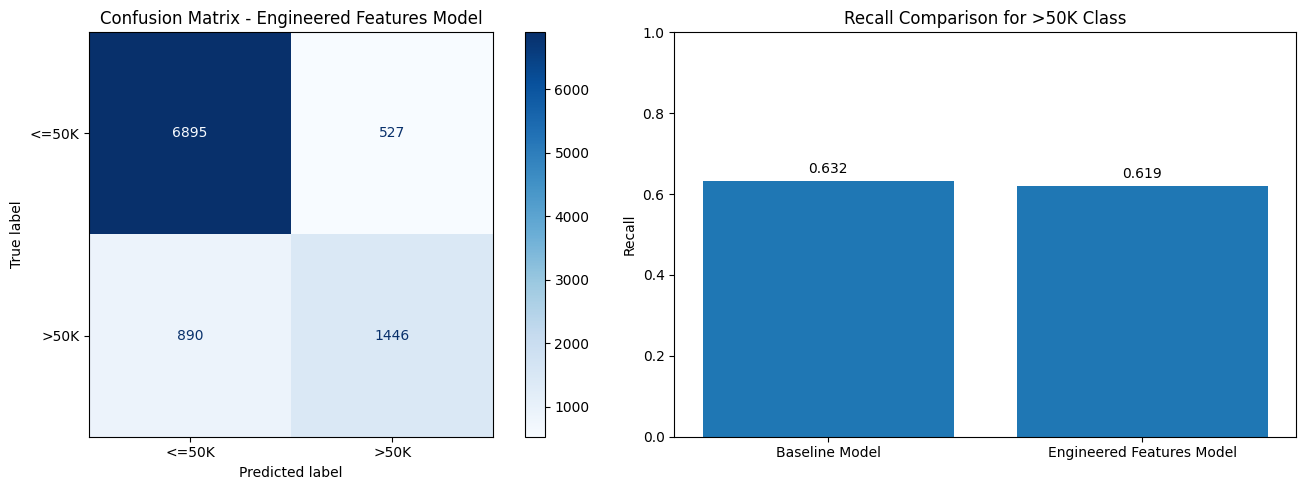

Baseline Recall: 0.632277397260274
Engineered Features Recall: 0.6190068493150684


In [41]:
# Step 5: Train Random Forest model with engineered features

rf_engineered = RandomForestClassifier(random_state=42)

# Fit the model on engineered training features
rf_engineered.fit(X_train_engineered, y_train)

# Make predictions
engineered_train_preds = rf_engineered.predict(X_train_engineered)
engineered_test_preds = rf_engineered.predict(X_test_engineered)

# Evaluate the model
print("Classification Report: Training Data")
print(classification_report(y_train, engineered_train_preds))

print("Classification Report: Test Data")
print(classification_report(y_test, engineered_test_preds))


# Confusion Matrix and Recall Comparison for engineered features model

from sklearn.metrics import ConfusionMatrixDisplay, recall_score
import matplotlib.pyplot as plt

# Calculate recall for engineered features model
engineered_recall = recall_score(
    y_test,
    engineered_test_preds,
    pos_label='>50K'
)

# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    engineered_test_preds,
    ax=axes[0],
    cmap='Blues'
)

axes[0].set_title('Confusion Matrix - Engineered Features Model')

# Plot recall comparison
recall_scores = {
    'Baseline Model': baseline_recall,
    'Engineered Features Model': engineered_recall
}

axes[1].bar(recall_scores.keys(), recall_scores.values())
axes[1].set_title('Recall Comparison for >50K Class')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)

# Add recall values above bars
for i, value in enumerate(recall_scores.values()):
    axes[1].text(i, value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

print("Baseline Recall:", baseline_recall)
print("Engineered Features Recall:", engineered_recall)


### Engineered Features Model Evaluation

After applying PCA and adding 3 principal components to the original processed features, I trained a new Random Forest model using the engineered feature set.

The engineered features model achieved similar overall accuracy to the baseline model. However, the recall for the `>50K` class slightly decreased from about 0.632 in the baseline model to about 0.619 after adding the PCA features.

This means that the PCA feature engineering step did not improve the model’s ability to identify people who actually earn `>50K`. Since recall for the `>50K` class is the main metric in this project, the baseline model performed slightly better than the engineered features model.

# 2.Apply at least one method of feature selection to your new features including engineered data.
Fit and evaluate a final model using the selected features.
Compare it with previous models.

In [42]:
# Step 6: Apply feature selection using SelectFromModel

from sklearn.feature_selection import SelectFromModel

# Create feature selector using Random Forest
selector = SelectFromModel(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    threshold='median')

# Fit selector only on training data
selector.fit(X_train_engineered, y_train)

# Transform train and test data
X_train_selected = selector.transform(X_train_engineered)
X_test_selected = selector.transform(X_test_engineered)

# Check shapes after feature selection
print("Before feature selection:", X_train_engineered.shape)
print("After feature selection:", X_train_selected.shape)

Before feature selection: (39032, 111)
After feature selection: (39032, 56)


### Feature Selection Result

I used `SelectFromModel` with a Random Forest model as an embedded feature selection method. This method selects features based on importance scores learned by the model.

Before feature selection, the engineered dataset had 111 features. After applying feature selection, 56 features were selected. These selected features will be used to train the final model.

Classification Report: Training Data
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     29687
        >50K       1.00      1.00      1.00      9345

    accuracy                           1.00     39032
   macro avg       1.00      1.00      1.00     39032
weighted avg       1.00      1.00      1.00     39032

Classification Report: Test Data
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7422
        >50K       0.74      0.62      0.68      2336

    accuracy                           0.86      9758
   macro avg       0.81      0.78      0.79      9758
weighted avg       0.85      0.86      0.85      9758



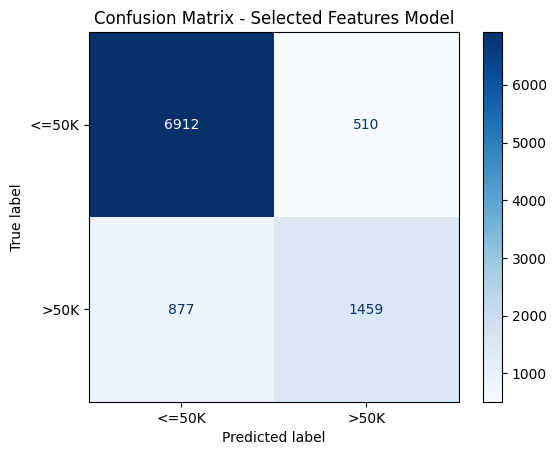

In [46]:
# Step 7: Train final model using selected features and evaluate it

rf_selected = RandomForestClassifier(random_state=42, n_jobs=-1)

# Fit final model
rf_selected.fit(X_train_selected, y_train)

# Make predictions
selected_train_preds = rf_selected.predict(X_train_selected)
selected_test_preds = rf_selected.predict(X_test_selected)

# Classification reports
print("Classification Report: Training Data")
print(classification_report(y_train, selected_train_preds))

print("Classification Report: Test Data")
print(classification_report(y_test, selected_test_preds))

# Confusion Matrix for selected features model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_test_preds,
    cmap='Blues'
)

plt.title('Confusion Matrix - Selected Features Model')
plt.show()

### Selected Features Model Evaluation

After feature selection, the number of features was reduced from 111 to 56. The final Random Forest model achieved 0.86 accuracy on the test data.

For the `>50K` class, recall was 0.62, meaning the model correctly identified about 62% of actual high-income individuals. The confusion matrix shows that 1,459 `>50K` cases were predicted correctly, while 877 were missed.

Overall, feature selection made the model simpler, but it did not fully improve recall for the `>50K` class.

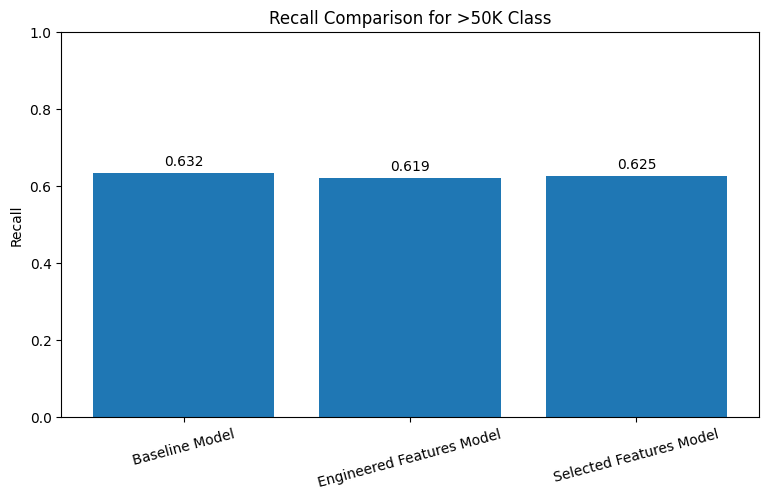

Baseline Recall: 0.632277397260274
Engineered Features Recall: 0.6190068493150684
Selected Features Recall: 0.6245719178082192


In [47]:
# Step 8: Compare recall scores for all models

from sklearn.metrics import recall_score

# Calculate recall for selected features model
selected_recall = recall_score(
    y_test,
    selected_test_preds,
    pos_label='>50K'
)

# Store recall scores
recall_scores = {
    'Baseline Model': baseline_recall,
    'Engineered Features Model': engineered_recall,
    'Selected Features Model': selected_recall
}

# Plot recall comparison
plt.figure(figsize=(9, 5))
bars = plt.bar(recall_scores.keys(), recall_scores.values())

plt.title('Recall Comparison for >50K Class')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=15)

# Add recall values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f'{height:.3f}',
        ha='center'
    )

plt.show()

print("Baseline Recall:", baseline_recall)
print("Engineered Features Recall:", engineered_recall)
print("Selected Features Recall:", selected_recall)

### Recall Comparison

This chart compares the recall for the `>50K` class across three models: the baseline model, the engineered features model, and the selected features model.

The baseline model had the highest recall at about 0.632. After adding PCA features, recall decreased slightly to about 0.619. After applying feature selection, recall improved slightly to about 0.625, but it was still lower than the baseline model.

This means that PCA feature engineering and feature selection did not improve recall compared to the original baseline model. Since recall for the `>50K` class is the main metric, the baseline model remains the best model among the three.

In [48]:
# Extract and visualize top 10 features using permutation importance

# Step 9: Permutation Importance for the selected features model


# Create recall scorer for >50K class
recall_scorer = make_scorer(
    recall_score,
    pos_label='>50K'
)

# Calculate permutation importance using recall
selected_perm_importance = permutation_importance(
    rf_selected,
    X_test_selected,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring=recall_scorer
)

In [49]:
# Get feature names after preprocessing

processed_feature_names = fe_preprocessor.get_feature_names_out()

# Add PCA feature names
pca_feature_names = ['PC1', 'PC2', 'PC3']

# Combine original processed feature names with PCA feature names
engineered_feature_names = list(processed_feature_names) + pca_feature_names

# Get only selected feature names
selected_feature_names = pd.Series(engineered_feature_names)[selector.get_support()]

selected_feature_names.head()

,0
0,num__age
1,num__fnlwgt
2,num__educational-num
3,num__capital-gain
4,num__capital-loss


In [50]:
# Create dataframe for permutation importance results

selected_importance_df = pd.DataFrame({
    'feature': selected_feature_names.values,
    'importance': selected_perm_importance.importances_mean
})

# Sort and get top 10
selected_top_10_features = selected_importance_df.sort_values(
    by='importance',
    ascending=False
).head(10)

selected_top_10_features

,feature,importance
53,PC1,0.199743
23,cat__marital-status_Married-civ-spouse,0.110616
0,num__age,0.064127
40,cat__relationship_Husband,0.054880
2,num__educational-num,0.042551
54,PC2,0.039041
3,num__capital-gain,0.031079
5,num__hours-per-week,0.027483
44,cat__relationship_Wife,0.021661
41,cat__relationship_Not-in-family,0.019863


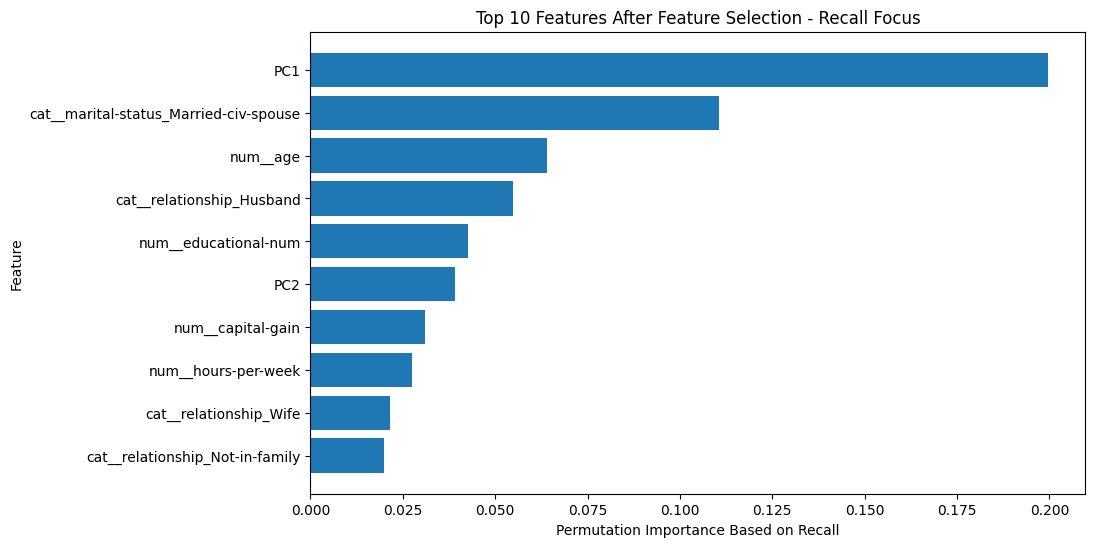

In [51]:
# Plot top 10 features after feature selection

plt.figure(figsize=(10, 6))
plt.barh(
    selected_top_10_features['feature'],
    selected_top_10_features['importance']
)

plt.xlabel('Permutation Importance Based on Recall')
plt.ylabel('Feature')
plt.title('Top 10 Features After Feature Selection - Recall Focus')
plt.gca().invert_yaxis()
plt.show()

### Top 10 Features After Feature Selection

After applying feature selection, I used permutation importance with recall as the scoring metric to identify the top 10 features for the final model.

The most important feature was `PC1`, which is one of the new PCA features created during feature engineering. Other important features included `marital-status_Married-civ-spouse`, `age`, `relationship_Husband`, `educational-num`, `PC2`, `capital-gain`, `hours-per-week`, `relationship_Wife`, and `relationship_Not-in-family`.

Compared to the model from Part 1, several similar features remained important, such as marital status, relationship, age, education, capital gain, and hours per week. However, the new PCA features `PC1` and `PC2` also appeared in the top 10. This shows that the engineered PCA features captured useful information from the original data, even though they did not improve recall compared to the baseline model.

#In a Markdown cell, comment on how these features compare to the model from Part 1. Are there any new features in the top 10?

-Yes, PC1 and PC2 appeared in the top 10.